In [24]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [25]:
import sys, os

def add_path(p: str):
    if p not in sys.path:
        sys.path.append(p)

add_path(os.environ['LP_ROOT'])
import project

add_path(os.environ['PROJECT'] + '/' + 'param_search')
import param_search as ps

ps.set_backend('sge')
ps.set_verbose(False)

# Gather examples

In [26]:
from pathlib import Path
#data_root = Path(os.environ['LP_ROOT'] / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'
data_root.is_dir()

True

In [27]:
import pandas as pd
subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = list(pd.read_csv(subject_file, sep='\t').sid)
len(subject_list)

1000

# Setup experiment

In [28]:
base_dir = '2026-09-15_preprocess'

template = '''\
#!/bin/bash -l
#$ -N {job_name}
#$ -P batmanlab
#$ -pe omp 4
#$ -l gpus=1
#$ -l gpu_memory=32G
#$ -l h_rt=3:00:00
set -eo pipefail

mamba activate $PROJECT/mambaforge/envs/warp

export PYTHONPATH=$LP_ROOT:$PROJECT:$PYTHOPATH

python $LP_ROOT/scripts/preprocess.py {config} \\
    --set dataset.subjects=[{subject}] \\
    --set dataset.variant={variant} \\
    --set dataset.pipeline_tags.forward_simulation={fwd_tag} \\
    --set preprocessing.forward_simulation.pde_solver.material_type={mat_type}

'''
name_format = 'job_{params_hash}'

grid = ps.param_grid(
    config='2026-09-15_config.yaml',
    subject=subject_list,
    variant='2026-09-15',
    fwd_tag='LE',
    mat_type='linear'
)

len(grid)

1000

In [29]:
jobs = ps.setup(base_dir, template, name_format, grid, overwrite=False)
jobs

OSError: /projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene/2026-09-15_preprocess/job_dff3f5b4c40b66ce/run.sh already exists

In [43]:
jobs = ps.submit(jobs)

In [30]:
jobs = ps.load(base_dir)
jobs

,job_name,job_state,n_submits,job_id,node_id,runtime,stdout,stderr,base_dir,work_dir,...,params.fwd_tag,params.mat_type,array_idx,last_live_at,state_source,finalized,finalized_at,output_exists,output_fsize,output_mtime
0,job_dff3f5b4c40b66ce,SUBMITTED,1,7588038,None,None,├── 'optimizer': dict(len=2)\n | ├──...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
1,job_31be35a7a76de560,SUBMITTED,1,7588039,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 4 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
2,job_e0ce5aae5fcc604f,SUBMITTED,1,7588040,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: Interpolation points outside domain: ...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
3,job_63f85f291aaa8ce6,SUBMITTED,1,7588041,None,None,Module project.physics.warp.forms.linear_elast...,"\r 0%| | 0/1 [00:00<?, ?it/s]\r100%|...",/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
4,job_98d44af8ed9a7c8e,SUBMITTED,1,7588042,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 2 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,job_664e21ade655d01d,SUBMITTED,1,7589035,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: Interpolation points outside domain: ...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
996,job_8c8f24c657c51935,SUBMITTED,1,7589036,None,None,├── 'optimizer': dict(len=2)\n | ├──...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
997,job_0ad80fc533d333c8,SUBMITTED,1,7589037,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 3 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None
998,job_137c03d7e44152a3,SUBMITTED,1,7589038,None,None,Module project.physics.warp.forms.linear_elast...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,None,None


In [31]:
%autoreload
jobs = ps.recover(jobs)
jobs = ps.status(jobs)
jobs = ps.history(jobs) # not working for SGE backend; job_state may be stale
jobs = ps.collect(jobs)
jobs

,job_name,job_state,n_submits,job_id,node_id,runtime,stdout,stderr,base_dir,work_dir,...,params.fwd_tag,params.mat_type,array_idx,last_live_at,state_source,finalized,finalized_at,output_exists,output_fsize,output_mtime
0,job_dff3f5b4c40b66ce,SUBMITTED,1,7588038,None,None,├── 'optimizer': dict(len=2)\n | ├──...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
1,job_31be35a7a76de560,SUBMITTED,1,7588039,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 4 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
2,job_e0ce5aae5fcc604f,SUBMITTED,1,7588040,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: Interpolation points outside domain: ...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
3,job_63f85f291aaa8ce6,SUBMITTED,1,7588041,None,None,Module project.physics.warp.forms.linear_elast...,"\r 0%| | 0/1 [00:00<?, ?it/s]\r100%|...",/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
4,job_98d44af8ed9a7c8e,SUBMITTED,1,7588042,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 2 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,job_664e21ade655d01d,SUBMITTED,1,7589035,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: Interpolation points outside domain: ...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
996,job_8c8f24c657c51935,SUBMITTED,1,7589036,None,None,├── 'optimizer': dict(len=2)\n | ├──...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
997,job_0ad80fc533d333c8,SUBMITTED,1,7589037,None,None,Module project.physics.warp.forms.linear_elast...,WARNING: mesh has 3 components\nWARNING: Inter...,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>
998,job_137c03d7e44152a3,SUBMITTED,1,7589038,None,None,Module project.physics.warp.forms.linear_elast...,,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,LE,linear,NaN,None,None,None,None,False,<NA>,<NA>


In [32]:
jobs.groupby('job_state').count()

,job_name,n_submits,job_id,node_id,runtime,stdout,stderr,base_dir,work_dir,script_path,...,params.fwd_tag,params.mat_type,array_idx,last_live_at,state_source,finalized,finalized_at,output_exists,output_fsize,output_mtime
job_state,,,,,,,,,,,,,,,,,,,,,
SUBMITTED,1000,1000,1000,0,0,1000,1000,1000,1000,1000,...,1000,1000,0,0,0,0,0,1000,0,0


In [35]:
def classify_error(stderr):

    if pd.isnull(stderr):
        return 'No stderr file'
        
    elif not str(stderr).strip():
        return 'No error message'

    elif 'Segmentation fault' in stderr:
        return 'Segmentation fault'
    
    elif 'CUDA out of memory' in stderr or ('Failed to allocate' in stderr and "bytes on device 'cuda" in stderr):
        return 'CUDA out of memory'

    elif 'Warp CUDA error' in stderr:
        return 'Warp CUDA error'
        
    elif 'Non-positive density' in stderr:
        return 'Non-positive density'
        
    elif 'construct initial points' in stderr or 'Exuding' in stderr or ('Moving #' in stderr and 'addr:' in stderr):
        return 'pygalmesh output'

    elif 'WARNING' in stderr:
        return 'Uncategorized warning'

    return 'Uncategorized error'

jobs['error_type'] = jobs.stderr.map(classify_error)
jobs.groupby('error_type')[['job_name']].count()

,job_name
error_type,
No error message,154
Non-positive density,2
Segmentation fault,4
Uncategorized warning,839
Warp CUDA error,1


In [61]:
error_type = 'Non-positive density'
error_jobs = jobs[jobs.error_type == error_type]
error_jobs

,job_name,job_state,n_submits,job_id,node_id,runtime,stdout,stderr,base_dir,work_dir,...,params.mat_type,array_idx,last_live_at,state_source,finalized,finalized_at,output_exists,output_fsize,output_mtime,error_type
851,job_079323b87a8a953d,SUBMITTED,1,7588891,None,None,INFO: Running stage interpolate_mesh_fields\nL...,"File ""/projectnb/batmanlab/mragoza/lung-proj...",/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,linear,NaN,None,None,None,None,False,<NA>,<NA>,Non-positive density
906,job_9708ce50d189c933,SUBMITTED,1,7588946,None,None,INFO: Running stage interpolate_mesh_fields\nL...,"File ""/projectnb/batmanlab/mragoza/lung-proj...",/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,linear,NaN,None,None,None,None,False,<NA>,<NA>,Non-positive density


In [60]:
job = error_jobs.iloc[0]
print(job)
print(job.stdout)
print(job.stderr)

job_name                                        job_77101e101b901b92
job_state                                                  SUBMITTED
n_submits                                                          1
job_id                                                       7588964
node_id                                                         None
runtime                                                         None
stdout                Kernel cache:\n     /usr2/collab/mragoza/.c...
stderr               File "/projectnb/batmanlab/mragoza/mambaforg...
base_dir           /projectnb/batmanlab/mragoza/lung-project/note...
work_dir           /projectnb/batmanlab/mragoza/lung-project/note...
script_path        /projectnb/batmanlab/mragoza/lung-project/note...
output_path        /projectnb/batmanlab/mragoza/lung-project/note...
log_dir            /projectnb/batmanlab/mragoza/lung-project/note...
stdout_path        /projectnb/batmanlab/mragoza/lung-project/note...
stderr_path        /projectnb/batm

In [54]:
from project.common import transforms, interpolation
import numpy as np
from scipy.ndimage import distance_transform_edt

mesh_path = '/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-09-15/18395R/meshes/18395R_EXP_iso_v3d_gil_INSP_lung_375_bela_int.xdmf'
mask_path = '/restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-09-15/18395R/masks/18395R_EXP_iso_v3d_lung.nii.gz'

mesh = project.fileio.load_meshio(mesh_path)
nifti = project.fileio.load_nibabel(mask_path)

mask = nifti.get_fdata() > 0
affine = nifti.affine

points = transforms.world_to_voxel_coords(mesh.points, affine)
values = interpolation.interpolate_array(mask.astype(float), points)

p = points[values == 0][0]
i, j, k = np.floor(p).astype(int)

print(mask[i:i+2,j:j+2,k:k+2])

dist = distance_transform_edt(~mask)

print(dist[i-2:i+5,j-2:j+5,k-2:k+5])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-09-15/18395R/meshes/18395R_EXP_iso_v3d_gil_INSP_lung_375_bela_int.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/2026-09-15/18395R/masks/18395R_EXP_iso_v3d_lung.nii.gz
[[[False False]
  [False False]]

 [[False False]
  [False False]]]
[[[0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 1. 1. 0. 0.]
  [0. 0. 1. 1. 1. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 1. 1. 1. 0. 0.]
  [0. 0. 1. 1. 1. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0.]
 

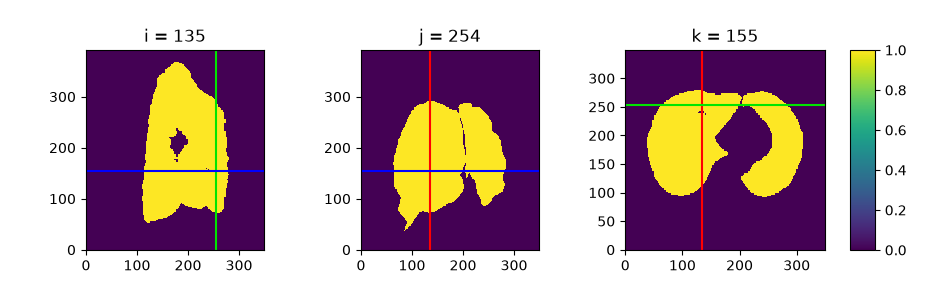

In [56]:
import project.visual.matplotlib as mpl_viz

mpl_viz.SliceViewer(mask, index=(i,j,k))

In [25]:
jobs.loc[:, 'job_id'] = pd.NA

In [28]:
%autoreload
jobs = ps.submit(jobs)
jobs

,job_name,job_state,n_submits,job_id,node_id,runtime,stdout,stderr,base_dir,work_dir,...,params_json,params_hash,params.config,params.data_name,params.data_root,params.subject,params.mat_tag,params.fwd_tag,params.mat_type,params.variant
0,jobead9ab1e5bc03c66,SUBMITTED,1,7159234,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",ead9ab1e5bc03c66,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,16514P,bela,linear,linear,2026-08-08
1,job96ef0272ef81ee7e,SUBMITTED,1,7159235,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",96ef0272ef81ee7e,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,20748Q,bela,linear,linear,2026-08-08
2,job4d5d759871906077,SUBMITTED,1,7159236,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",4d5d759871906077,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,11007Z,bela,linear,linear,2026-08-08
3,job62c1bdeb21500ce0,SUBMITTED,1,7159237,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",62c1bdeb21500ce0,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,14771Z,bela,linear,linear,2026-08-08
4,job1a856f1cecae8f51,SUBMITTED,1,7159238,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",1a856f1cecae8f51,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,13651K,bela,linear,linear,2026-08-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,job22f2adacb02a421c,SUBMITTED,1,7160229,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",22f2adacb02a421c,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,20519B,bela,linear,linear,2026-08-08
996,jobb1e67f498dc392b6,SUBMITTED,1,7160230,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",b1e67f498dc392b6,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,12294H,bela,linear,linear,2026-08-08
997,job2f617f39d23060c8,SUBMITTED,1,7160231,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",2f617f39d23060c8,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,23123R,bela,linear,linear,2026-08-08
998,jobbef061b64dfcfc4e,SUBMITTED,1,7160232,<NA>,<NA>,<NA>,<NA>,/projectnb/batmanlab/mragoza/lung-project/note...,/projectnb/batmanlab/mragoza/lung-project/note...,...,"{""config"": ""2026-08-08_config.yaml"", ""data_nam...",bef061b64dfcfc4e,/projectnb/batmanlab/mragoza/lung-project/note...,COPDGene,/restricted/projectnb/batmanlab/mragoza/data/C...,16546C,bela,linear,linear,2026-08-08
